# **Sistemi Lineari: Metodi iterativi**
Consideriamo un sistema lineare nella forma

$$\mathbf{A}\mathbf{x}=\mathbf{b},$$

dove $\mathbf{A}\in\mathbb{R}^{n\times n}$ e $\mathbf{b}\in\mathbb{R}^{n}$ sono noti, mentre $\mathbf{x}\in\mathbb{R}^{n}$ è il vettore incognito.


I medoti di Jacobi, Gauss-Seidel, Richardson, e del gradiente (eccezione fatta per il metodo del gradiente precondizionato) sono accomunati dallo schema iterativo

$$
  \mathbf{x}^{k+1} = \mathbf{B}^k \mathbf{x}^k + \mathbf{g},
$$

con $\mathbf{B}^k = \mathbf{I} - \alpha_k\mathbf{P}^{-1}\mathbf{A}$ e $\mathbf{g} = \mathbf{P}^{-1}\mathbf{b}$.

Segue:

$$
  \mathbf{x}^{k+1} = (\mathbf{I} - \alpha_k\mathbf{P}^{-1}\mathbf{A})\mathbf{x}^k + \mathbf{P}^{-1}\mathbf{b}, \tag{1}
$$

quest'ultima equazione, per una nuova prospettiva, può essere riscritta come

$$
  \mathbf{x}^{k+1} = \mathbf{x}^k + \mathbf{P}^{-1}\mathbf{r}^k,
$$

dove $\mathbf{r}^k$ è il residuo, $\mathbf{r}^k = \mathbf{b}-\mathbf{A}\mathbf{x}^k$.

</br>

**Metodo di Jacobi**: $\mathbf{P} = \text{diag}(\mathbf{A})$, $\alpha_k = 1$.

**Metodo di Gauss-Seidel**: $\mathbf{P} = \text{tril}(\mathbf{A})$, $\alpha_k = 1$.

**Metodo di Richardson stazionario**: $\mathbf{P}$ in base al precondizionatore desiderato, $\alpha_k = \alpha$.

**Metodo del gradiente**: $\mathbf{P}$ in base al precondizionatore desiderato, $\alpha_k = \frac{(\mathbf{d}^k)^T\mathbf{r}^k}{(\mathbf{d}^k)^T\mathbf{A}\mathbf{r}^k}$.


</br></br>

**Nota**: I metodi di Jacobi e Gauss-Seidel vengono tipicamente presentati attraverso la divisione della matrice $\mathbf{A} = \mathbf{D} - \mathbf{E} - \mathbf{F}$, dove $\mathbf{D}$ è la diagonale di $\mathbf{A}$, $-\mathbf{E}$ la triangolare inferiore escludendo la diagonale, $-\mathbf{F}$ la triangolare superiore escludendo la diagonale.  
Lo schema iterativo di Jacobi può essere scritto come
$$
  \mathbf{D}\mathbf{x}^{k+1} = (\mathbf{D}-\mathbf{A})\mathbf{x}^k + \mathbf{b},
$$
ossia
\begin{equation*}
\begin{aligned}
  \mathbf{x}^{k+1} &= \mathbf{D}^{-1}(\mathbf{D}-\mathbf{A})\mathbf{x}^k + \mathbf{D}^{-1}\mathbf{b},\\
   &= \mathbf{D}^{-1}(\mathbf{E}+\mathbf{F})\mathbf{x}^k + \mathbf{D}^{-1}\mathbf{b},
\end{aligned}
\end{equation*}
mentre lo schema di Gauss-Seidel può essere scritto come
$$
  (\mathbf{D} - \mathbf{E})\mathbf{x}^{k+1} = \mathbf{F}\mathbf{x}^k + \mathbf{b},
$$
ossia
$$
  \mathbf{x}^{k+1} = (\mathbf{D} - \mathbf{E})^{-1}\mathbf{F}\mathbf{x}^k + (\mathbf{D} - \mathbf{E})^{-1}\mathbf{b}.
$$


## Parte 1 - Implementazione

In [1]:
# import librerie e funzioni
import numpy as np
# funzione per la risoluzione di sistemi triangolari
from scipy.linalg import solve_triangular
# funzione per gli autovalori
from scipy.linalg import eigvals
from scipy.linalg import eigvalsh

<mark>**Esercizio 1**</mark></br>
Scrivere una function chiamata *jacobi_bg* che, dati $\mathbf{A}$ e $\mathbf{b}$, restituisce la matrice d'iterazione $\mathbf{B}$ ed il vettore di shifting $\mathbf{g}$ associati al metodo di Jacobi. Scrivere quindi una seconda funzione, *gauss_seidel_bg*, che faccia la stessa cosa ma per il metodo di Gauss-Seidel.

Hint: per Jacobi, $\mathbf{P}^{-1}$ è nota in forma chiusa. Per Gauss-Seidel sfruttate la funzione *solve_triangular* del pacchetto *scipy.linalg*.

In [2]:
# Jacobi
def jacobi_bg(A, b=None):
    """
    Metodi di Jacobi
    Input:
    A: matrice quadrata
    b: termine noto (facoltativo)
    Output:
    B: matrice di iterazione di Jacobi
    g: vettore di shifting di Jacobi (se abbiamo come input b)
    """

    # Definisco P^-1, che è possibile dato che P è una matrice diagonale
    P_inv=np.diag(1/np.diag(A))

    # Costruisco la matrice di iterazione
    B=np.eye(A.shape[0])-P_inv @ A

    if( b is None): #se non ho input, funzione ritorna B
        return B
    else: #se ho vettore b la funzione crea il vettore di shifting
        g= P_inv @ b
        return B, g

In [3]:
# Gauss-Seidel
def gauss_seidel_bg(A, b=None):
    """
    Metodi di Gauss-Seidel
    Input:
    A: matrice quadrata
    b: termine noto (facoltativo)
    Output:
    B: matrice di iterazione di Gauss-Seidel
    g: vettore di shifting di Gauss-Seidel (se abbiamo come input b)
    """
    P=np.tril(A) #retituisce la triangolare inferiore con anche la diagonale
    P_inv_A=solve_triangular(P, A, lower=True) #questa funzione ci consente di risolvere un sistema triangolare: P è la matrice e A è il termine noto, poi devo inserire lower=true o lower=false per specificare se il sistema è triangolare inferiore o superiore
    B = np.eye(A.shape[0]) - P_inv_A   #convieme mettere la shape di A perché è l'unico dato certo che abbiamo
    
    if( b is None): #se non ho input, funzione ritorna B
        return B
    else: #se ho vettore b la funzione crea il vettore di iterazione 
        g = solve_triangular(P, b, lower=True)
        return B, g

<mark>**Esercizio 2**</mark></br>
Scrivere una function chiamata *iterative_solve* che, dati

- $\mathbf{A}$ matrice del sistema
- $\mathbf{b}$ termine noto
- $\mathbf{x}_{0}$ guess iniziale
- $\mathbf{B}$ matrice di iterazione
- $\mathbf{g}$ vettore di shifting

approssimi la soluzione $\mathbf{x}$ con il metodo iterativo corrispondente. La function dovrà accettare anche altri due parametri: **nmax**, cioè il numero massimo di iterazioni, **rtoll**, la tolleranza relativa richiesta. Il particolare, il metodo iterativo va arrestato se

$$\frac{\|\mathbf{r}^{(k)}\|}{\|\mathbf{b}\|}<\textbf{rtoll},$$

dove $\mathbf{r}^{(k)}:= \mathbf{b} - \mathbf{A}\mathbf{x}^{(k)}$ è il residuo alla *k*-esima iterazione.

*Nota*: costruite la function di modo che, in output, essa restituisca la lista delle iterate $[\mathbf{x}_{0},\dots,\mathbf{x}_{N}]$.

In [4]:
def iterative_solve(A, b, x0, B, g, nmax, rtoll):
    """
    Metodo di risoluzione utilizzando i metodi iterativi

    Input:
    A: matrice quadrata
    b: termine noto
    x0: vettore di innesco
    B: matrice di iterazione
    g: vettore di shifting
    nmax: numero massimo di iterazioni
    rtoll: tolleranza relativa richiesta

    Output:
    xiter: lista contenente tutte le iterate
    """

    # inizializzazione
    bnorm=np.linalg.norm(b)
    xold=x0
    xiter=[x0]

    n=0 #è il contatore delle iterazioni
    err=1+rtoll #inizializzo l'errore in modo tale da poter entrare nel ciclo

    while (n<nmax and err>rtoll):

        # passo iterativo
        xnew=B @ xold + g
        # carico la lista xiter
        xiter.append(xnew)
        # residuo di xnew
        r=b - A @ xnew 
        # test di arresto
        err=np.linalg.norm(r)/bnorm
        #aggiorno
        xold=xnew
        n=n+1
    return xiter

## Parte 2 - Sperimentazione

<mark>**Esercizio 3**</mark></br>
Si consideri la seguente matrice quadrata


$$\mathbf{A}=\left[\begin{array}{cccccc}
1 & 1 & 1 & 1 & \dots & 1\\
R_{1} & - R_{2} & 0 & 0 & \dots & 0\\
0 & R_{1} & - R_{2} & 0 &  \dots & 0\\
\dots & 0 & \ddots & \ddots &   & \dots\\
\dots & \dots &  & \ddots &  \ddots & \dots\\
0 & 0 & 0 & \dots & R_{1} & - R_{2} \\
\end{array}\right]$$


di dimensione $n=100$, avendo posto $R_{1}=1$ ed $R_{2}=2$.
</br></br>

a) Assemblare le matrici di iterazione $B_{\text{J}}$ e $B_{\text{GS}}$ dei metodi di Jacobi e Gauss-Seidel, quindi calcolarne i rispettivi raggi spettrali. La condizione
necessaria e sufficiente per la convergenza del metodo iterativo è soddisfatta in entrambi i casi?

*Hint: Usare la function $\texttt{eigvals}$ di $\texttt{scipy.linalg}$ per il calcolo degli autovalori.*
</br></br>

b) Sia $\mathbf{b}=[2,1,1,\dots,1]^{\top}\in\mathbb{R}^{n}$. Approssimare la soluzione del sistema lineare $\mathbf{A}\mathbf{x}=\mathbf{b}$ con il metodo di Jacobi. Si pongano $$\mathbf{x}_{0}=[0,\dots,0]^{\top},\quad\texttt{rtoll}=10^{-6},\quad\texttt{nmax}=1000.$$ Il metodo converge? Se sì, in quante iterazioni?

In [5]:
# Costruzione della matrice A
n = 100
R1, R2 = 1, 2

A = -R2*np.diag(np.ones(n))
A[0, :] = 1
A = A + R1*np.diag(np.ones(n-1), -1)

In [6]:
# a) Raggi spettrali

# calcolo le matrici di iterazione di Jacobi e GS
B_j=jacobi_bg(A)
B_gs=gauss_seidel_bg(A)

# calcolo i raggi spettrali
rho_j=np.max(np.abs(eigvals(B_j)))
rho_gs=np.max(np.abs(eigvals(B_gs)))

# Stampo i raggi spettrali di Jacobi e Gauss-Seidel
print('raggio spettrale jacobi %.4f' %rho_j)
print('raggio spettrale gauss-seidel %.4f' %rho_gs)


raggio spettrale jacobi 0.7071
raggio spettrale gauss-seidel 1.0000


In [7]:
# b)
#  termine noto
b=np.ones(n)
b[0]=2

# Guess iniziale
x0 = np.zeros(n)

# Applicazione di Jacobi
B_j, g_j= jacobi_bg(A,b)
xiter=iterative_solve(A, b, x0, B_j, g_j, 1000, 1e-6)

# Numero di iterazioni
print(len(xiter)-1)

47


<mark>**Esercizio 4**</mark></br>
Si considerino la matrice e il termine noto
</br>
</br>
\begin{equation*}
\mathbf{A}=\left[\begin{array}{rrrrrrr}
9 & -3 & 1 &  &  & & \\
-3 & 9 & -3 & 1 &  & & \\
1 & -3 & 9 & -3 & 1 & & \\
& 1 & -3 & 9 & -3 & 1 &\\
& & 1 & -3 & 9 & -3 & 1 \\
& & & 1 & -3 & 9 & -3  \\
& & & & 1 & -3 & 9  \\
\end{array}\right],\quad\quad \mathbf{b}=\left[\begin{array}{c}7\\4\\5\\5\\5\\4\\7\end{array}\right].
\end{equation*}
</br>
a) Studiare le caratteristiche della matrice $\mathbf{A}$, stabilendo se sia simmetrica, definita positiva e a dominanza diagonale per righe $^*$.
</br></br>
b) Approssimare la soluzione del sistema lineare $\mathbf{A}\mathbf{x}=\mathbf{b}$ con i metodi di Jacobi e di Gauss-Seidel, utilizzando il vettore nullo come guess iniziale. Si pongano $$\texttt{rtoll}=10^{-6} \quad \text{and} \quad \texttt{nmax}=1000.$$ 
Confrontare il numero
di iterazioni necessarie per arrivare a convergenza per i due metodi e commentare i risultati
ottenuti.
</br>
</br>
La soluzione esatta del sistema lineare è $\mathbf{x}=[1, 1, 1, 1, 1, 1, 1]^T$.
</br>
</br>
</br>
</br>
$^*$*Hint: sfruttare la function $\texttt{eigvalsh}$ del pacchetto $\texttt{scipy.linalg}$, che restituisce gli autovalori per una matrice simmetrica o Hermitiana.*

In [8]:
# a) Assemblaggio di A e check delle proprietà

n = 7
A = -3 * np.diag(np.ones(n-1), 1) + np.diag(np.ones(n-2), 2)
A = 9 * np.diag(np.ones(n)) + A + A.T
print(A)

#si vede a occhio che la matrice è simmetrica
#si vede a occhio che la matrice è a dominanza diagonale per righe

#per vedere se la matrice è definita positiva stampo il minimo autovalore e se esso è positivo allora saranno tutti positivi e quindi la matrice è definita positiva:
print(np.min(eigvalsh(A)))

[[ 9. -3.  1.  0.  0.  0.  0.]
 [-3.  9. -3.  1.  0.  0.  0.]
 [ 1. -3.  9. -3.  1.  0.  0.]
 [ 0.  1. -3.  9. -3.  1.  0.]
 [ 0.  0.  1. -3.  9. -3.  1.]
 [ 0.  0.  0.  1. -3.  9. -3.]
 [ 0.  0.  0.  0.  1. -3.  9.]]
4.904226454981305


In [9]:
# b) Applicazione dei metodi e confronto
b = np.array([7, 4, 5, 5, 5, 4, 7])

# guess iniziale
x0 = np.zeros(n)

# risolvo Jacobi e Guass-Seidel
B_j, g_j=jacobi_bg(A,b)
B_gs, g_gs= gauss_seidel_bg(A, b)

xj=iterative_solve(A, b, x0, B_j, g_j, 1000, 1e-6)
xgs=iterative_solve(A, b, x0, B_gs, g_gs, 1000, 1e-6)

print('numero di iterazioni Jacobi: %d' %(len(xj)-1))
print('numero di iterazioni gauss Seidel: %d' %(len(xgs)-1))

numero di iterazioni Jacobi: 49
numero di iterazioni gauss Seidel: 12


In [10]:
# Tabella che mi stampa la convergenza e il numero di iterazioni
print("\t\t\tJacobi\tGauss-Seidel\n" + "-"*44)
print("Convergenza:\t\t%s\t%s" % (len(xj)-1 < 1000, len(xgs)-1 < 1000))
print("Numero di iterazioni:\t%d\t%d" % (len(xj)-1, len(xgs)-1))

			Jacobi	Gauss-Seidel
--------------------------------------------
Convergenza:		True	True
Numero di iterazioni:	49	12


## Parte 3 - Metodi pre-implementati: gradiente e gradiente coniugato

<mark>**Esercizio 5**</mark></br>
La function $\texttt{cg}$ del pacchetto $\texttt{scipy.sparse.linalg}$ implementa il metodo del gradiente coniugato. Viceversa, la function $\texttt{gdescent}$, disponibile nello script $\texttt{utils.py}$, implementa il metodo del gradiente.
</br></br>
Una volta appurato che entrambi i metodi sono applicabili al problema dell'esercizio 5
</br></br>
a) Approssimare la soluzione del sistema con i metodi del gradiente e del gradiente coniugato. Si utilizzino gli stessi iperparametri usati all'es. 5 (guess iniziale, tolleranza relativa, numero massimo di iterazioni). I metodi convergono? Che soluzione si ottiene?
</br></br>
b) Nei due casi, quante iterazioni ci sono volute? *Hint: per $\texttt{cg}$, sfruttate l'input opzionale $\texttt{callback}$*!

In [11]:
from utils import gdescent
xg = gdescent(A, b, x0, nmax=10000, rtoll=1e-5)

print("Soluzione approssimata (Gradient descent):")
print(xg[-1])

# numero iterazioni metodo del gradiente
print("Numero di iterazioni effettuate: %d" % (len(xg)-1))

Soluzione approssimata (Gradient descent):
[0.99999958 0.99999228 0.99999331 0.99998581 0.99999331 0.99999228
 0.99999958]
Numero di iterazioni effettuate: 17


In [12]:
from scipy.sparse.linalg import cg

# Definisco la lista con la guess iniziale
xcg = [x0]
# chiamo la function cg del gradiente coniugato
x, info = cg(A, b, x0, rtol=1e-6, maxiter=1000,
             callback=lambda xk: xcg.append(xk+0.0))

print("\nSoluzione approssimata (CG):")
print(x)
print("Numero di iterazioni effettuate: %d" % (len(xcg)-1))


Soluzione approssimata (CG):
[1. 1. 1. 1. 1. 1. 1.]
Numero di iterazioni effettuate: 4


## Esercizi per casa

<mark>**Esercizio 6**</mark></br>
Scrivete le seguenti function a valori booleani (vero o falso):

- **sym** che, data $\mathbf{A}$, restituisce $\texttt{True}$ se e solo se $\mathbf{A}$ è simmetrica;

- **sdp** che, data $\mathbf{A}$, restituisce $\texttt{True}$ se e solo se $\mathbf{A}$ è simmetrica definita positiva;

- **rowdom** che, data $\mathbf{A}$, restituisce $\texttt{True}$ se e solo se $\mathbf{A}$ è a dominanza diagonale per righe.

In [13]:
def sym(A):
    return np.max(np.abs(A-A.T)) < 1e-15

def sdp(A):
    if sym(A):
        return np.max(np.linalg.eigvals(A))>0
    else:
        return False

def rowdom(A):
    righe=A.shape[0]
    col=A.shape[1]
    B=A-np.diag(np.diag(A))
    for i in range(righe):
        somma=0
        for j in range (col):
            somma=somma+np.abs(B[i,j])
        if somma>=np.abs(A[i,i]):
            return False
        
    return True

rowdom(A)           


True

<mark>**Esercizio 7**</mark></br>
Si considerino la matrice pentadiagonale ed il termine noto
\begin{equation*}
\mathbf{A}=\left[\begin{array}{rrrrrrr}
5 & -1 & -1 &  &  & & \\
-1 & 5 & -1 & -1 &  & & \\
-1 & -1 & 5 & -1 & -1 & & \\
& \ddots  & \ddots & \ddots & \ddots & \ddots  &\\
& & -1 & -1 & 5 & -1 & -1 \\
& & &  -1 & -1 & 5 & -1 \\
& & & & -1 & -1 & 5 \\
\end{array}\right],\quad\quad \mathbf{b}=\left[\begin{array}{c}0.2\\0.2\\0.2\\\vdots\\0.2\\0.2\\0.2\end{array}\right].
\end{equation*}
</br>
a) La matrice $\mathbf{A}$ è simmetrica definitiva positiva?
</br></br>
b) Approssimare la soluzione del sistema lineare con i metodi di Jacobi, Gauss-Seidel, Gradiente e Gradiente Coniugato (si utilizzi il vettore nullo come guess iniziale, $10^{-5}$ come tolleranza relativa, $1000$ come numero massimo di iterazioni).
</br></br>
c) Plottare l'andamento del residuo relativo $\|\mathbf{r}^{(k)}\|/\|\mathbf{b}\|$ in funzione delle iterate $k$, mettendo così a paragone i quattro metodi.


In [14]:
# a) Assemblaggio matrice e check proprietà
n=50
A=-1*np.ones((n,n)) #ho costruito matrice n*n di uni
A=A-6*np.diag(np.diag(A)) #sulla diagonale (fatta di -1) sommo +6 in modo da avere diagonale di 5
print(A)

print("A è simmetrica definita positiva:")
print(sdp(A))



[[ 5. -1. -1. ... -1. -1. -1.]
 [-1.  5. -1. ... -1. -1. -1.]
 [-1. -1.  5. ... -1. -1. -1.]
 ...
 [-1. -1. -1. ...  5. -1. -1.]
 [-1. -1. -1. ... -1.  5. -1.]
 [-1. -1. -1. ... -1. -1.  5.]]
A è simmetrica definita positiva:
True


In [15]:
# b) Applicazione dei metodi iterativi
x0=np.zeros(n)
b=0.2*np.ones(n)
# Gradiente
xg=gdescent(A,b, x0, 1000, 1e-5)
print("Soluzione con metodo del gradiente:")
print(xg[-1])

# Gradiente coniugato (sfruttiamo il callback per salvare le iterate: ci servirà dopo)
xgc=[x0]
xgc_fin, info=cg(A, b, x0, rtol=1e-5, maxiter=1000, callback=lambda xk: xcg.append(xk+0.0))
print("Soluzione con metodo del gradiente coniugato:")
print(xgc_fin)

# Jacobi
Bj, gj= jacobi_bg(A,b)
xj=iterative_solve(Bj, gj, x0,Bj, gj, 1000, 1e-5)
print("Soluzione con metodo di Jacobi:")
print(xj[-1])

# Gauss-Seidel
Bgs, ggs =gauss_seidel_bg(A, b)
xgs=iterative_solve(Bgs,ggs, x0, Bgs, ggs, 1000, 1e-5)
print("Soluzione con metodo di Gauss-Seidel:")
print(xgs[-1])



Soluzione con metodo del gradiente:
[-0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545
 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545
 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545
 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545
 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545
 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545
 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545
 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545
 -0.00454545 -0.00454545]
Soluzione con metodo del gradiente coniugato:
[-0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545
 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545
 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545
 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545 -0.00454545
 -0.00454545 -0.

/usr/local/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/tmp/ipykernel_3505/830749731.py:33: RuntimeWarning: overflow encountered in matmul
  r=b - A @ xnew
/tmp/ipykernel_3505/830749731.py:29: RuntimeWarning: overflow encountered in matmul
  xnew=B @ xold + g
/tmp/ipykernel_3505/830749731.py:33: RuntimeWarning: invalid value encountered in matmul
  r=b - A @ xnew


In [16]:
# c) Calcolo dei residui e plot
bnorm=np.linalg.norm(b)
rg=[np.linalg.norm(A @ xk - b)/bnorm for xk in xg]
rgc=[np.linalg.norm(A @ xk - b)/bnorm for xk in xgs]
rj=[np.linalg.norm(A @ xk - b)/bnorm for xk in xj]
rgs=[np.linalg.norm(A @ xk - b)/bnorm for xk in xgs]


/tmp/ipykernel_3505/3389369743.py:4: RuntimeWarning: overflow encountered in matmul
  rgc=[np.linalg.norm(A @ xk - b)/bnorm for xk in xgs]
/tmp/ipykernel_3505/3389369743.py:4: RuntimeWarning: invalid value encountered in matmul
  rgc=[np.linalg.norm(A @ xk - b)/bnorm for xk in xgs]
/tmp/ipykernel_3505/3389369743.py:5: RuntimeWarning: overflow encountered in matmul
  rj=[np.linalg.norm(A @ xk - b)/bnorm for xk in xj]
/tmp/ipykernel_3505/3389369743.py:5: RuntimeWarning: invalid value encountered in matmul
  rj=[np.linalg.norm(A @ xk - b)/bnorm for xk in xj]
/tmp/ipykernel_3505/3389369743.py:6: RuntimeWarning: overflow encountered in matmul
  rgs=[np.linalg.norm(A @ xk - b)/bnorm for xk in xgs]
/tmp/ipykernel_3505/3389369743.py:6: RuntimeWarning: invalid value encountered in matmul
  rgs=[np.linalg.norm(A @ xk - b)/bnorm for xk in xgs]


Text(0, 0.5, 'Residuo relativo')

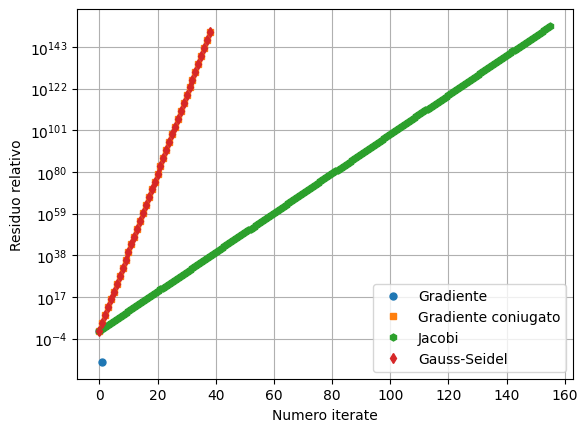

In [17]:
import matplotlib.pyplot as plt

# Plot in scala logaritmica sulle y
plt.figure()
plt.semilogy(rg, 'o', label='Gradiente', markersize=5)
plt.semilogy(rgc, 's', label='Gradiente coniugato', markersize=5)
plt.semilogy(rj, 'h', label='Jacobi', markersize=5)
plt.semilogy(rgs, 'd', label='Gauss-Seidel', markersize=5)
plt.grid()
plt.legend()
plt.xlabel('Numero iterate')
plt.ylabel('Residuo relativo')



In [18]:
help(plt.grid)

Help on function grid in module matplotlib.pyplot:

grid(visible: 'bool | None' = None, which: "Literal['major', 'minor', 'both']" = 'major', axis: "Literal['both', 'x', 'y']" = 'both', **kwargs) -> 'None'
    Configure the grid lines.

    Parameters
    ----------
    visible : bool or None, optional
        Whether to show the grid lines.  If any *kwargs* are supplied, it
        is assumed you want the grid on and *visible* will be set to True.

        If *visible* is *None* and there are no *kwargs*, this toggles the
        visibility of the lines.

    which : {'major', 'minor', 'both'}, optional
        The grid lines to apply the changes on.

    axis : {'both', 'x', 'y'}, optional
        The axis to apply the changes on.

    **kwargs : `~matplotlib.lines.Line2D` properties
        Define the line properties of the grid, e.g.::

            grid(color='r', linestyle='-', linewidth=2)

        Valid keyword arguments are:

        Properties:
        agg_filter: a filter fun